## Introducción

Este proyecto tiene como objetivo **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello se trabajará con datos reales de TomTom Traffic Index y OECD Cities, se desarrollará con porcesos como limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.
La orientación es ejercer las actividades cotidianas de un análista de datos desarrollando con práctica la lectura de los datos obtenidos orientados a la toma de decisiones.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario entender la estructura de ambos datasets.
En esta etapa, validé que los archivos se carguen correctamente, identifiqué sus columnas y tipos de datos, busqué posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Etapas:**
- Importar las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Cargar los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guardar los DataFrames en las variables `traffic` y `eco`.
- Mostrar las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, es importarte inspeccionar su estructura, tipos de datos, columnas y valores faltantes.
Anotar las columnas que necesiten limpieza y luego estandarizar los nombres de columnas es una excelente práctica.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Etapas:**

- Usar `.info()` para conocer la estructura de ambos DataFrames.
- Mostrar los primeros 3 renglones de cada DF.
- Identificar si los detalles de cada DF estan bien o si requieren correcciones y escribir las conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato tienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object, por lo que deben ser normalizadas
- Hay 8 columnas númericas tipo float (JamsDelay, TrafficIndexLive, JamsLenthInKms, JamsCount, TrafficIndexWeekAgo, TravelTimeLivePer10KmsMins, TravelTimeHistoricPer10KmsMins, MinsDelay)
- El nombre de la ciudad no cuenta con la primera letra mayúscula (Title Case).
- Los valores de la columna Country se ven estandarizados

In [6]:
# Examinar la estructura de eco
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment % son datos númericos porcentuales pero estan como object
- Las columnas 'PM2.5(μg/m³)' y 'Population' son datos númericos pero estan como object
- La columna 'Year' deberia ser datatime.year y actualmente esta en int64
- Columna 'Country' normalizada
- Columna ciudad tiene formato kebab-case

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Etapas:**

- Cambiar los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verificar que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns = {"Country":"country", "City":"city", "UpdateTimeUTC":"update_time_utc", "JamsDelay":"jams_delay",
                          "TrafficIndexLive":"traffic_index_live", "JamsLengthInKms":"jams_length_in_kms", "JamsCount": "jams_counts", 
                         "TrafficIndexWeekAgo":"traffic_index_week_ago", "UpdateTimeUTCWeekAgo":"update_time_utc_week_ago",
                         "TravelTimeLivePer10KmsMins":"travel_time_live_per_10_kms_mins", "TravelTimeHistoricPer10KmsMins":
                         "travel_time_historic_per_10_kms_mins", "MinsDelay":"mins_delay"})	
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_counts',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco.columns = eco.columns.str.replace(" ","_").str.replace("/", "_").str.replace("%", "pct").str.lower()
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5_(μg_m³)', 'population_(m)'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Etapas:**

- Convertir las columnas de fecha de `traffic` a formato `datetime`. Contemplar el cambio a prueba de errores.
- En el dataset `eco`, limpiar los valores numéricos:
    - En `city_gdp_capita`: eliminar separadores de miles (`.`) y reemplazar las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: eliminar el símbolo de porcentaje (`%`) y reemplazar las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplazar las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crear una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"], errors = "coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors = "coerce")

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_length_in_kms                    1004464 non-null  float64       
 6   jams_counts                           1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [ ]:
# Limpiar separadores y convertir columnas numéricas en eco

eco["city_gdp_capita"] = eco["city_gdp_capita"].astype(str).str.replace(".", "").str.replace(",", ".").astype(float)

eco["unemployment_pct"] = eco["unemployment_pct"].astype(str).str.replace("%", "").str.replace(",", ".").astype(float)

eco["population_(m)"] = eco["population_(m)"].astype(str).str.replace(",", ".").astype(float)
# Calcular la población total en unidades absolutas (Multiplicar * 1000000)

eco["population"] = eco["population_(m)"]*1000000
# verificar el cambio

eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5_(μg_m³)     30 non-null     object 
 6   population_(m)    30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_(μg_m³),population_(m),population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Etapas**

- Como el DataFrame `traffic` no tiene una columna de año, utilizar el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtrar las filas donde el año sea **2024**.
- Utilizar `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc

traffic["year"] = traffic["update_time_utc"].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_counts,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtrar los registros del año 2024

traffic_2024 = traffic[traffic["year"] == 2024].copy()

eco_2024 = eco[eco["year"] == 2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_counts,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_(μg_m³),population_(m),population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, se calculará los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Etapas**

- Agrupar los datos por `city`, `country` y `year`.
- Calcular el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guardar el resultado como `traffic_city_year_2024`, mantener las columnas como variables (no índices).


In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
# creo columnas de agrupación
groups_cols = ["city", "country", "year"]
# creo métricas mas relevantes
metric_cols = ["jams_delay", "traffic_index_live", "jams_length_in_kms", "jams_counts", "mins_delay", "travel_time_live_per_10_kms_mins", "travel_time_historic_per_10_kms_mins"]
# calculo promedio de las metricas relevantes
traffic_city_year_2024 =  traffic_2024.groupby(groups_cols)[metric_cols].agg("mean").reset_index()
# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_counts,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


###  **Previsualización**

En este punto nos detenemos para realizar una visualización previa de los datos obtenidos.

Formulo preguntas generales que inicien un contexto de la información:

- ¿Cuál ciudad tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecutamos esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`

In [ ]:
# Le damos reset al id de los registros
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).reset_index()

,index,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_counts,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
1,352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
2,246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
3,200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
4,211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...,...
382,111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
383,363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
384,123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
385,12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de Mexico con un jams_delay = 2833.0579


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Etapas**
- Seleccionar solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usar `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Unir ambos DataFrames y definir como **claves de unión** a `city` y `year`.
- Mantener solo las ciudades y años presentes en ambos datasets.
- Guardar el resultado en una nueva variable llamada `merged` y mostrar las primeras 5 filas.


In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_counts','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm2.5_(μg_m³)','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()

eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=["city", "year"], how="inner")
# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_counts,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp_capita,unemployment_pct,pm2.5_(μg_m³),population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tenemos un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Etapas**
- Usar las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualizar la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualizar la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **comparar ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Agregar título y etiquetas a los ejes de los gráficos.
- Observar y contar los patrones, valores extremos o posibles relaciones que se identifiquen.

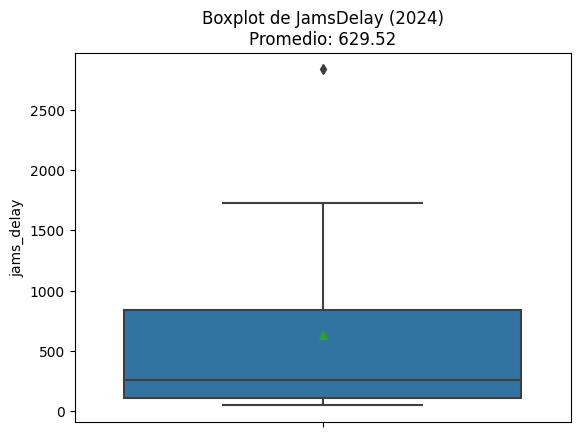

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# Agregar `showmeans=True` para ver la media en el gráfico.
sns.boxplot(data=merged, y="jams_delay", showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


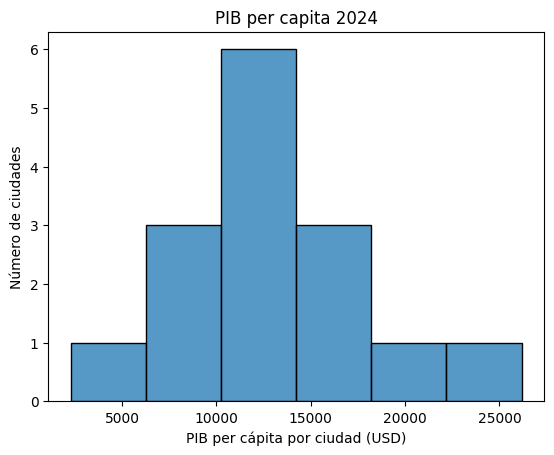

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x="city_gdp_capita")
plt.title("PIB per capita 2024")
plt.xlabel("PIB per cápita por ciudad (USD)")
plt.ylabel("Número de ciudades")
plt.show()

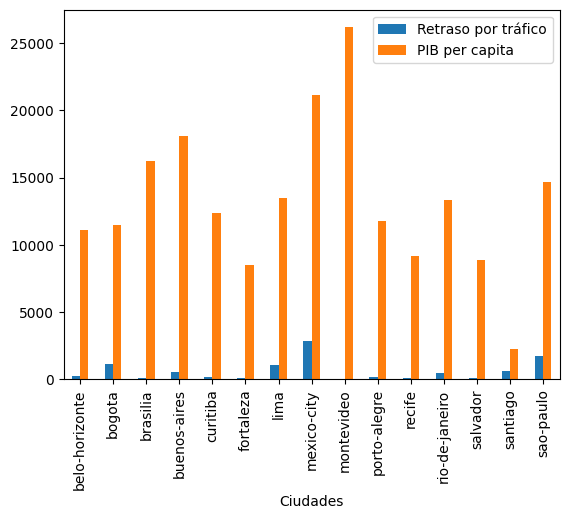

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind="bar", y=["jams_delay","city_gdp_capita"], x="city")
plt.xlabel("Ciudades")
plt.legend(["Retraso por tráfico", "PIB per capita"])
plt.xticks(rotation=90)
plt.show()

###  **Previsualización**
Nuevamente nos detenemos para hacer una revisión de los gráficos obtenidos.

Formulo preguntas para tener contexto de la información arrojada en los diferentes gráficos:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Comentarios: 

- Es importante aclarar que el gráfico al ser de barras presenta una disparidad de escalas considerable, lo que dificulta un poco la visualización rápida, sin embargo, podemos establecer que no hay una relación sostenible entre la congestión del gráfico y el PIB per cápita.
  


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidamos todo el trabajo: guardaremos el dataset limpio y crearemos un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Etapas**

- Exportar el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usar `index=False` para no incluir el índice.


In [19]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

## ✅ Entregables

1. **Notebook `.ipynb`**.
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown.


## RESUMEN EJECUTIVO

### CONTEXTO
Para este estudio se analizaron los datasets de TomTom Traffic Index y OECD Cities (PIB per cápita, desempleo y población), se dieron determinados rangos para limitar el alcance del análisis:

        - Solo se tuvieron en cuenta datos correspondientes al año 2024
        - El alcance se limitó a paises del continente sur americano y Mexico
        - Se incluyeron unicamente las ciudades que contaban con los datos necesarios en ambos datasets para poder tener fiabilidad y eficiencia de análisis después de la unión.

Se utilizaron las librerias de python: Pandas, Numpy, Seaborn y Matplotlib.

Para poder contar con información fiable se realizaron diferentes procesos de limpieza y organización de datos, luego de cargar los datasets se cambiaron los tipos de datos en campos como fechas o de valores númericos, se uso el formato snake_case para renombrar las columnas y finalmente se filtro la información para solo tener en cuenta datos correspondientes al 2024. Una vez normalizada la      información se agrupo por las variables Ciudad/Año y se obtuvo el promedio anual por ciudad para evitar gran cantidad de registros y tener la información más condensada; una vez preparada y              asegurada la información en ambos datasets se realizó unión con INNER usando Ciudad/Año como claves de unión. Para finalizar y tener una idea clara y visual se genero un boxplot para congestión, un      histograma con los datos del PIB per cápita y se unió la información de ambas variables (jams_delay, city_gdp_capita) en un gráfico de barras.

### HALLAZGOS

Realmente no se puede establecer una relación directa entre la congestión del tráfico y el inidice de distribución per cápita del PIB, tenemos el ejemplo de Montevideo en Uruguay donde el PIB es el más alto (26.176) y la congestión presenta el valor más bajo (50.20), pero así mismo tenemos la situación con la Ciudad de México que tiene el segundo PIB más alto (21.111) y en congestión al contrario de Montevideo representa el valor más alto de congestión (2.833). Sin embargo es importante aclarar que la media y mediana de los datos se encuentran en valores inferiores a 1000 para la congestión de tráfico, pero hay outliers altisimos que halan el promedio y pueden llegar a distorsionan el análisis, lo que establece que aunque el tráfico la mayor parte del tiempo es mas moderado, hay situaciones puntuales de congestión que agudizan las lecturas.
Por otro lado si se puede establecer una tendencia de congestión causada por la población de las ciudades, ya que podemos evidenciar que los dos valores más altos de congestión también coinciden con las ciudades mas pobladas del estudio, y los dos siguientes valores altos de congestión también corresponden a ciudades con poblaciones por encima de los 10 millones de habitantes. Esto también nos da un indicio de que las ciudades mas pobladas tiene que tener un indice de PIB per cápita muy alto para poder gestionar la movilidad de sus densas poblaciones.


### RECOMENDACIONES

Se recomienda ampliar el análisis para entender que causa la dispersión de los datos en el tráfico de algunas ciudades como Ciudad de México, Sao Paulo, Bogotá y Lima. Para ello también se recomienda priorizar la inversión ya que si se logra estabilizar el tráfico evitando esos datos puntuales tan altos, se logrará establecer mas eficientemente como afectan esos cambios al crecimiento de la economía para esas ciudades.

Es importante establecer como crecen las ciudades demograficamente y cual es la gestión por parte de entidades gubernamentales para asegurar el PIB requerido sin impactar la productividad a causa del alto tráfico.

Los datos de Santiago de Chile muestran que aunque presenta un tráfico estable sin outliers considerables sigue siendo alto y representa por mucho el valor mas bajo de PIB per cápita, se sugiere un análisis mas detallado para entender como esto puede afectar su economía y salud de la población

    
       